# ***Initialization***

In [1]:
# Importing some library files...
import sklearn
import pandas as pd
import numpy as np
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from pandas.core.dtypes.common import is_numeric_dtype
import pickle
import random
import warnings as wr
wr.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn import tree

import seaborn as sns

default_fig_size_inch = 20

In [2]:
# Fetching the Dataset for training...
path = "raw_dataset.csv"
df = pd.read_csv(path)
target = 'button_rank'
print(len(df))
df.head()

518


,web_id,button_id,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,...,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website,button_rank
0,1.0,1.0,0.036458,0.417910,1.076923,0.02736,0.952381,1.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,1.000000
1,1.0,2.0,0.044922,0.514925,1.326923,0.02736,0.952381,1.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,0.500000
2,1.0,3.0,0.069661,0.798507,2.057692,0.02736,0.952381,1.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,0.666667
3,1.0,4.0,0.033854,0.388060,1.000000,0.02736,0.952381,1.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,0.333333
4,1.0,5.0,0.075521,0.865672,2.230769,0.02736,0.952381,1.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,0.833333


# ***Dataset Preprocessing***

***Dataset Cleaning***

In [3]:
print(len(df))
df = df.dropna()
print(len(df))
df = df.drop(["web_id", "button_id"], axis=1)
df.head()

518
518


,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website,button_rank
0,0.036458,0.417910,1.076923,0.02736,0.952381,1.0,0.0,0.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,1.000000
1,0.044922,0.514925,1.326923,0.02736,0.952381,1.0,0.0,0.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,0.500000
2,0.069661,0.798507,2.057692,0.02736,0.952381,1.0,0.0,0.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,0.666667
3,0.033854,0.388060,1.000000,0.02736,0.952381,1.0,0.0,0.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,0.333333
4,0.075521,0.865672,2.230769,0.02736,0.952381,1.0,0.0,0.0,0.0,0.0,...,0.0,7.0,0.714286,18.0,18.0,134.0,52.0,21.0,20.0,0.833333


In [4]:
# df.describe()
df.dtypes

button_width                                                   float64
button_width_ratio_with_largest_button_width                   float64
button_width_ratio_with_smallest_button_width                  float64
button_height                                                  float64
button_height_ratio_with_largest_button_height                 float64
button_height_ratio_with_smallest_button_height                float64
button_color_R                                                 float64
button_color_G                                                 float64
button_color_B                                                 float64
button_color_A                                                 float64
button_contrast_with_background                                float64
button_center_x_coordinate                                     float64
button_center_y_coordinate                                     float64
button_is_on_navbar                                            float64
button

***Synthetic Date Generation***

In [5]:
# def add_random_noise(df, noise_level=0.1):
#     noise = np.random.normal(scale=noise_level * df.std(), size=df.shape)
#     noisy_df = df + noise
#     noise
#     return noise

# noise = add_random_noise(df)
# noisy_df = df + noise

# print("Original DataFrame:")
# print(df.head())
# print("\nNoisy DataFrame:")
# print(noisy_df.head())

In [6]:
# !pip install git+https://github.com/nickkunz/smogn.git

In [7]:
# import smogn
# df_smogn = smogn.smoter(data = noisy_df, y = target)
# print(len(df))
# print(len(df_smogn))

***Feature Engineering***

In [8]:
features = ["button_width",
"button_width_ratio_with_largest_button_width",
"button_width_ratio_with_smallest_button_width",
"button_height",
"button_height_ratio_with_largest_button_height",
"button_height_ratio_with_smallest_button_height",
"button_color_R",
"button_color_G",
"button_color_B",
"button_color_A",
"button_contrast_with_background",
"button_center_x_coordinate",
"button_center_y_coordinate",
"button_is_on_navbar",
"button_is_on_footer",
"button_is_on_left_half_of_screen",
"button_is_on_right_half_of_screen",
"button_is_on_upper_half_of_screen",
"button_is_on_lower_half_of_screen",
"button_is_on_horizontal_center_of_screen",
"button_is_on_vertical_center_of_screen",
"total_number_of_buttons_in_radius_5_percent_of_screen_size",
"total_number_of_buttons_in_radius_10_percent_of_screen_size",
"total_number_of_buttons_in_radius_25_percent_of_screen_size",
"total_number_of_buttons_in_radius_50_percent_of_screen_size",
"button_text_size",
"button_text_size_ratio_with_largest_button_text",
"button_text_size_ratio_with_smallest_button_text",
"button_text_color_R",
"button_text_color_G",
"button_text_color_B",
"button_text_color_A",
"button_text_contrast_with_button",
"button_text_is_bold",
"button_text_is_italic",
"total_number_of_buttons_in_the_website",
"total_number_of_buttons_in_the_navbar",
"largest_button_text_in_the_website",
"smallest_button_text_in_the_website",
"largest_button_width_in_the_website",
"smallest_button_width_in_the_website",
"largest_button_height_in_the_website",
"smallest_button_height_in_the_website"]

normalize_these = ["button_width_ratio_with_smallest_button_width",
"button_height_ratio_with_smallest_button_height",
"button_text_size",
"button_text_size_ratio_with_smallest_button_text",
"total_number_of_buttons_in_the_website",
"largest_button_text_in_the_website",
"smallest_button_text_in_the_website",
"largest_button_width_in_the_website",
"smallest_button_width_in_the_website",
"largest_button_height_in_the_website",
"smallest_button_height_in_the_website"]

features_orig = features
df_orig = df

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Sample data (replace with your actual data)
#data = df

# Define columns to skip scaling
skip_cols = normalize_these

# Separate data
#data_to_scale = data[skip_cols]
#data_skipped = data[data.columns.difference(skip_cols)]

# Apply MinMaxScaler
scaler = MinMaxScaler()
df[skip_cols] = scaler.fit_transform(df[skip_cols])

# Combine dataframes
#combined_data = pd.concat([pd.DataFrame(scaled_data, columns=data_to_scale.columns), data_skipped], axis=1)

#combined_data
df

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website,button_rank
0,0.036458,0.417910,0.000257,0.027360,0.952381,0.00000,0.000000,0.000000,0.000000,0.0,...,0.0,0.15,0.714286,0.135135,1.0000,0.102119,0.083612,0.000000,0.326087,1.000000
1,0.044922,0.514925,0.001093,0.027360,0.952381,0.00000,0.000000,0.000000,0.000000,0.0,...,0.0,0.15,0.714286,0.135135,1.0000,0.102119,0.083612,0.000000,0.326087,0.500000
2,0.069661,0.798507,0.003537,0.027360,0.952381,0.00000,0.000000,0.000000,0.000000,0.0,...,0.0,0.15,0.714286,0.135135,1.0000,0.102119,0.083612,0.000000,0.326087,0.666667
3,0.033854,0.388060,0.000000,0.027360,0.952381,0.00000,0.000000,0.000000,0.000000,0.0,...,0.0,0.15,0.714286,0.135135,1.0000,0.102119,0.083612,0.000000,0.326087,0.333333
4,0.075521,0.865672,0.004116,0.027360,0.952381,0.00000,0.000000,0.000000,0.000000,0.0,...,0.0,0.15,0.714286,0.135135,1.0000,0.102119,0.083612,0.000000,0.326087,0.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,0.075972,0.710744,0.001150,0.039440,0.885714,0.00000,0.298039,0.686275,0.313725,1.0,...,0.0,0.15,0.000000,0.000000,0.6875,0.077071,0.103679,0.058577,0.565217,0.485714
514,0.068021,0.636364,0.000679,0.039440,0.885714,0.00000,0.298039,0.686275,0.313725,1.0,...,0.0,0.15,0.000000,0.000000,0.6875,0.077071,0.103679,0.058577,0.565217,0.342857
515,0.106890,1.000000,0.002979,0.044529,1.000000,0.00253,0.000000,0.482353,1.000000,1.0,...,0.0,0.15,0.000000,0.000000,0.6875,0.077071,0.103679,0.058577,0.565217,0.942857
516,0.095406,0.892562,0.002299,0.044529,1.000000,0.00253,0.862745,0.207843,0.270588,1.0,...,0.0,0.15,0.000000,0.000000,0.6875,0.077071,0.103679,0.058577,0.565217,0.914286


In [10]:
df.dtypes

button_width                                                   float64
button_width_ratio_with_largest_button_width                   float64
button_width_ratio_with_smallest_button_width                  float64
button_height                                                  float64
button_height_ratio_with_largest_button_height                 float64
button_height_ratio_with_smallest_button_height                float64
button_color_R                                                 float64
button_color_G                                                 float64
button_color_B                                                 float64
button_color_A                                                 float64
button_contrast_with_background                                float64
button_center_x_coordinate                                     float64
button_center_y_coordinate                                     float64
button_is_on_navbar                                            float64
button

In [11]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(df)
# df = pd.DataFrame(scaled_data, columns=df.columns)
# df

In [12]:
# df.drop(target, axis=1).columns == features

In [13]:
# temp = combined_data.columns.difference([target])
# features = temp
# df = combined_data

In [14]:
# Define Gini index function
def gini_index(feature):
    # Get unique values in feature
    values = df[feature].unique()
    # Calculate proportion of each value
    proportions = []
    for value in values:
        proportion = len(df[df[feature] == value]) / len(df)
        proportions.append(proportion)
    # Calculate Gini index
    gini = 1 - sum([p**2 for p in proportions])
    return gini

gini_scores = {}
for feature in features:
    gini_scores[feature] = gini_index(feature)

# Initialize List with feature names with Gini value 0
features_to_drop = []

gini_scores_reverse = {}

for feature, gini_score in sorted(gini_scores.items(), key=lambda x: x[1], reverse=True):
  gini_scores_reverse[gini_score] = []

for feature, gini_score in gini_scores.items():
  gini_scores_reverse[gini_score].append(feature)

print("Gini Score"," : ","Feature Names")
for gini_score, feature_names in gini_scores_reverse.items():
  print(gini_score," : ", end = ""), print(*feature_names, sep = ", ")

Gini Score  :  Feature Names
0.9962284402438844  : button_center_x_coordinate
0.995550155781816  : button_center_y_coordinate
0.9919276695338471  : button_width
0.9839522368479898  : button_width_ratio_with_largest_button_width
0.9821857157764491  : button_width_ratio_with_smallest_button_width
0.9799868815312829  : button_text_contrast_with_button
0.9764091173357582  : button_height
0.9752687049984344  : button_contrast_with_background
0.9728015384386038  : button_height_ratio_with_largest_button_height
0.9705132600885497  : largest_button_width_in_the_website
0.9599961240887882  : smallest_button_width_in_the_website
0.9521548575602629  : button_height_ratio_with_smallest_button_height
0.9467434892145317  : total_number_of_buttons_in_radius_25_percent_of_screen_size
0.9444552108644773  : largest_button_height_in_the_website
0.9311951223148134  : smallest_button_height_in_the_website
0.9153262473725796  : button_text_size_ratio_with_largest_button_text
0.9147597680416213  : total_numb

In [15]:
# Choosing one feature among many with same gini

for gini_score, feature_names in gini_scores_reverse.items():
  if gini_score == 0:
    unselected_features = feature_names
  else:
    selected_feature = random.choice(feature_names)
    unselected_features = [feature for feature in feature_names if feature != selected_feature]
  if len(unselected_features):
    print(*unselected_features, sep=",")
  features_to_drop.extend(unselected_features)

In [16]:
# Drop columns in 'gini_scores'
for feature in features_to_drop:
  del gini_scores[feature]

# Drop columns in 'skills' array
print(len(features))
features = [feature for feature in features if feature not in features_to_drop]
print(len(features))

# Drop columns in 'df' dataframe
df.drop(columns=features_to_drop, inplace=True)
df.tail()

43
43


,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website,button_rank
513,0.075972,0.710744,0.001150,0.039440,0.885714,0.00000,0.298039,0.686275,0.313725,1.0,...,0.0,0.15,0.0,0.0,0.6875,0.077071,0.103679,0.058577,0.565217,0.485714
514,0.068021,0.636364,0.000679,0.039440,0.885714,0.00000,0.298039,0.686275,0.313725,1.0,...,0.0,0.15,0.0,0.0,0.6875,0.077071,0.103679,0.058577,0.565217,0.342857
515,0.106890,1.000000,0.002979,0.044529,1.000000,0.00253,0.000000,0.482353,1.000000,1.0,...,0.0,0.15,0.0,0.0,0.6875,0.077071,0.103679,0.058577,0.565217,0.942857
516,0.095406,0.892562,0.002299,0.044529,1.000000,0.00253,0.862745,0.207843,0.270588,1.0,...,0.0,0.15,0.0,0.0,0.6875,0.077071,0.103679,0.058577,0.565217,0.914286
517,0.080389,0.752066,0.001411,0.039440,0.885714,0.00000,1.000000,0.756863,0.027451,1.0,...,0.0,0.15,0.0,0.0,0.6875,0.077071,0.103679,0.058577,0.565217,0.257143


***Train Test Split***

In [17]:
y = df[target]
X = df.drop(target, axis=1)
X.describe()

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_is_bold,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website
count,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,...,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000
mean,0.079136,0.570765,0.017513,0.062331,0.626819,0.030848,0.506102,0.479847,0.461837,0.824139,...,0.233591,0.003861,0.345174,0.092664,0.265783,0.556829,0.254045,0.087657,0.259228,0.446995
std,0.071999,0.260069,0.078549,0.035289,0.259035,0.081869,0.417780,0.362535,0.392243,0.347683,...,0.423524,0.062077,0.201651,0.192625,0.188173,0.233962,0.197582,0.106398,0.182596,0.230850
min,0.001302,0.003333,0.000000,0.006840,0.019231,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.046224,0.366667,0.001094,0.041439,0.427812,0.001634,0.000000,0.101961,0.000000,0.900000,...,0.000000,0.000000,0.250000,0.000000,0.189189,0.375000,0.123314,0.052676,0.125523,0.326087
50%,0.065755,0.552613,0.003227,0.054720,0.620690,0.009219,0.488235,0.498039,0.400000,1.000000,...,0.000000,0.000000,0.300000,0.000000,0.189189,0.500000,0.229287,0.076923,0.225941,0.434783
75%,0.091634,0.752176,0.007804,0.073871,0.839015,0.031419,1.000000,0.802941,0.864706,1.000000,...,0.000000,0.000000,0.400000,0.000000,0.297297,0.687500,0.302505,0.102007,0.330544,0.673913
max,0.626305,1.000000,1.000000,0.355677,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
# Splitting Data into Train and Test Sets...
SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

In [19]:
X_test2 = X_test[:1]
X_test2

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_is_bold,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website
176,0.105469,0.782609,0.009556,0.083447,0.693182,0.028235,0.501961,0.0,1.0,1.0,...,0.0,0.0,0.3,0.0,0.243243,0.4375,0.242775,0.06689,0.280335,0.434783


In [20]:
y_orig = df_orig[target]
X_orig = df_orig.drop(target, axis=1)
X_orig.describe()

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_is_bold,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website
count,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,...,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000
mean,0.079136,0.570765,0.017513,0.062331,0.626819,0.030848,0.506102,0.479847,0.461837,0.824139,...,0.233591,0.003861,0.345174,0.092664,0.265783,0.556829,0.254045,0.087657,0.259228,0.446995
std,0.071999,0.260069,0.078549,0.035289,0.259035,0.081869,0.417780,0.362535,0.392243,0.347683,...,0.423524,0.062077,0.201651,0.192625,0.188173,0.233962,0.197582,0.106398,0.182596,0.230850
min,0.001302,0.003333,0.000000,0.006840,0.019231,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.046224,0.366667,0.001094,0.041439,0.427812,0.001634,0.000000,0.101961,0.000000,0.900000,...,0.000000,0.000000,0.250000,0.000000,0.189189,0.375000,0.123314,0.052676,0.125523,0.326087
50%,0.065755,0.552613,0.003227,0.054720,0.620690,0.009219,0.488235,0.498039,0.400000,1.000000,...,0.000000,0.000000,0.300000,0.000000,0.189189,0.500000,0.229287,0.076923,0.225941,0.434783
75%,0.091634,0.752176,0.007804,0.073871,0.839015,0.031419,1.000000,0.802941,0.864706,1.000000,...,0.000000,0.000000,0.400000,0.000000,0.297297,0.687500,0.302505,0.102007,0.330544,0.673913
max,0.626305,1.000000,1.000000,0.355677,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
# Splitting Data into Train and Test Sets...
SEED = 42
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_orig, y_orig, test_size=0.25, random_state=SEED)

In [22]:
X_test2_orig = X_test_orig[:1]
X_test2_orig

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_is_bold,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website
176,0.105469,0.782609,0.009556,0.083447,0.693182,0.028235,0.501961,0.0,1.0,1.0,...,0.0,0.0,0.3,0.0,0.243243,0.4375,0.242775,0.06689,0.280335,0.434783


***Initializing Model Comparators***

In [23]:
#lists initiated that will contain the name of the models and their respective metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

names = []
mae = []
mse = []
rmse=[]
r2 = []

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

def add_to_metrics(y_true,y_pred,model_name,show=True):
  names.append(model_name)
  mae.append(mean_absolute_error(y_true, y_pred))
  mse.append(mean_squared_error(y_true, y_pred))
  rmse.append(np.sqrt(mean_squared_error(y_true, y_pred)))
  r2.append(r2_score(y_true, y_pred))

  if show:
    print("Mean Absolute Error (MAE):", mae[-1])
    print("Mean Squared Error (MSE):", mse[-1])
    print("Root Mean Squared Error (RMSE):", rmse[-1])
    print("R-squared (R²) Score:", r2[-1])

def visualize_results(y_test,y_pred):
  # Scatter plot of true vs. predicted values
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred, color='blue')
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line
  plt.title('True vs. Predicted Values')
  plt.xlabel('True Values')
  plt.ylabel('Predicted Values')
  plt.grid(True)
  plt.show()

  # Distribution plot of residuals
  residuals = y_test - y_pred
  plt.figure(figsize=(8, 6))
  sns.histplot(residuals, kde=True, color='blue')
  plt.title('Distribution of Residuals')
  plt.xlabel('Residuals')
  plt.ylabel('Frequency')
  plt.grid(True)
  plt.show()

# ***Decision Tree***

Mean Absolute Error (MAE): 0.20444041385345735
Mean Squared Error (MSE): 0.07524812599474064
Root Mean Squared Error (RMSE): 0.2743139187039926
R-squared (R²) Score: 0.13146008622986793


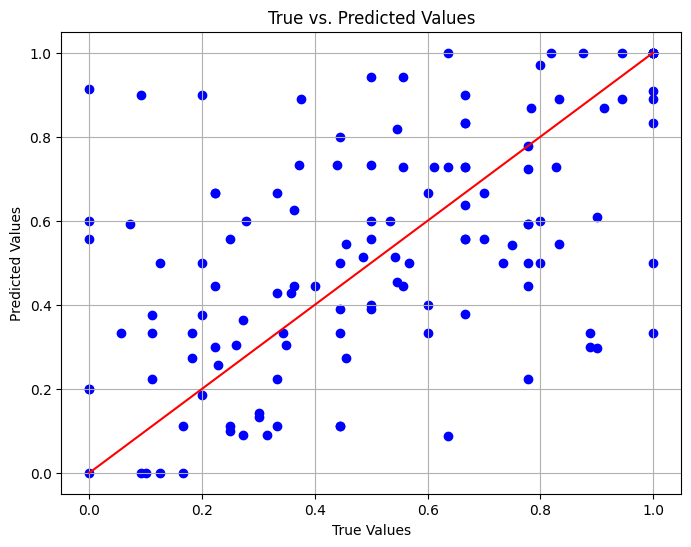

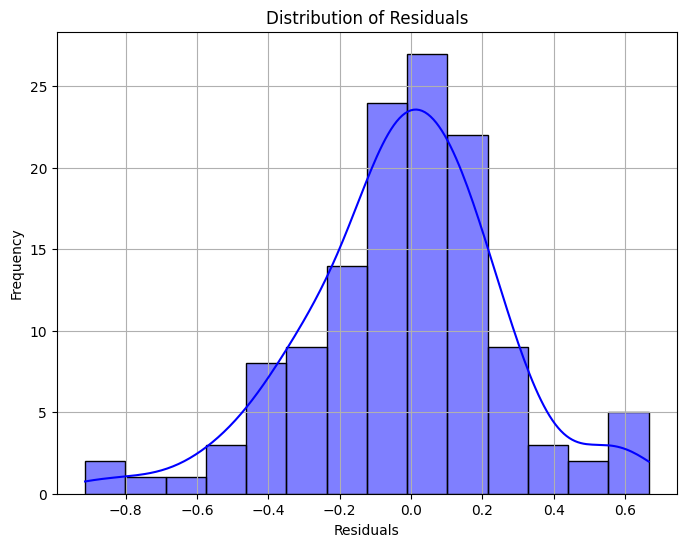

In [24]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
y_pred = dtr.predict(X_test)
add_to_metrics(y_test,y_pred,"DTR")
visualize_results(y_test,y_pred)

In [25]:
y_pred2 = dtr.predict(X_test2)
y_pred2

array([0.44444444])

# ***Random Forest***

Mean Absolute Error (MAE): 0.16651062116627335
Mean Squared Error (MSE): 0.042845669091130446
Root Mean Squared Error (RMSE): 0.20699195417003638
R-squared (R²) Score: 0.5054604583716144


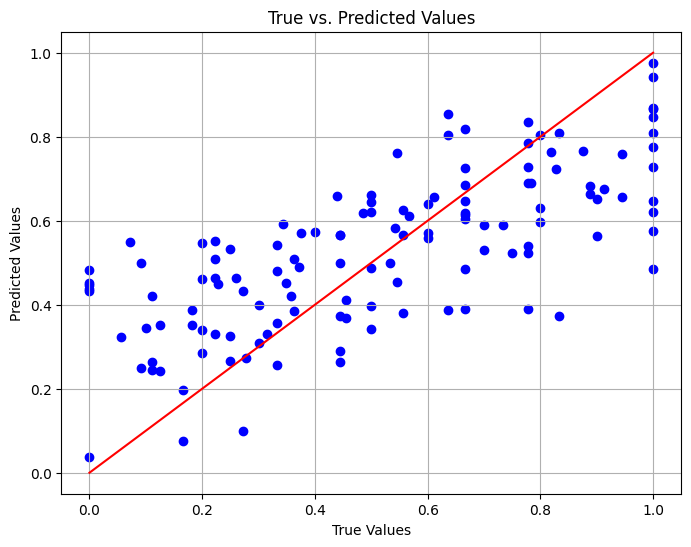

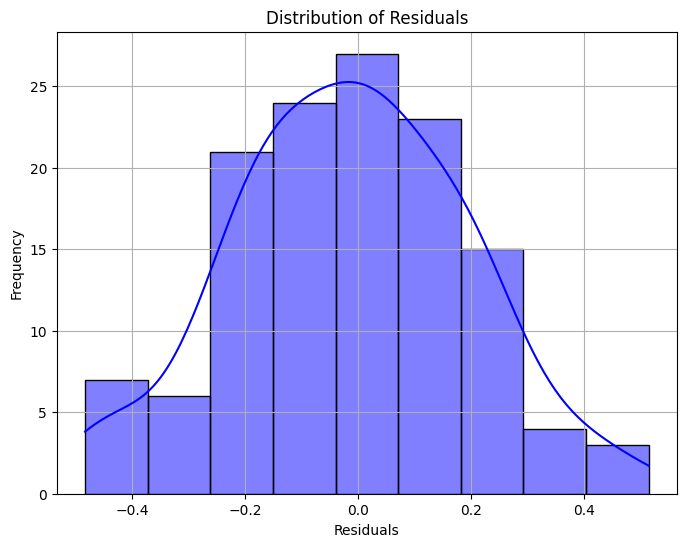

In [26]:
from sklearn.ensemble import RandomForestRegressor

rmf = RandomForestRegressor()
rmf.fit(X_train,y_train)
y_pred=rmf.predict(X_test)
add_to_metrics(y_test,y_pred,"RMF")
visualize_results(y_test,y_pred)

In [27]:
y_pred2 = rmf.predict(X_test2)
y_pred2

array([0.5399181])

# ***Gradient Boosting***

Mean Absolute Error (MAE): 0.1758328611577662
Mean Squared Error (MSE): 0.045499146510074466
Root Mean Squared Error (RMSE): 0.21330528945639032
R-squared (R²) Score: 0.4748331036279001


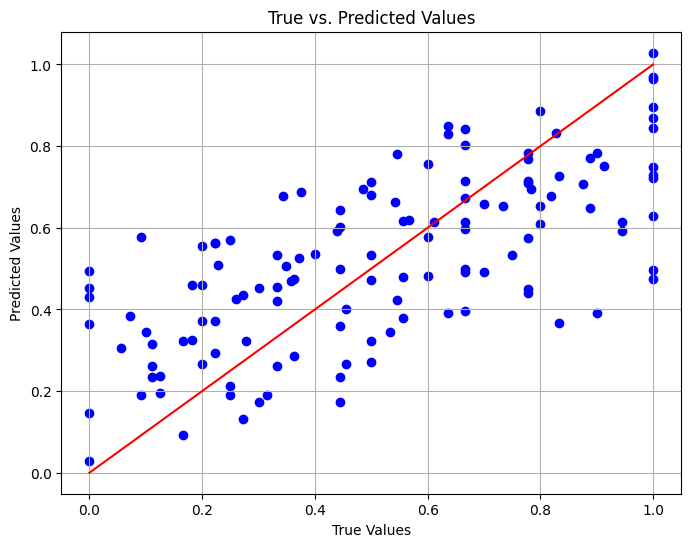

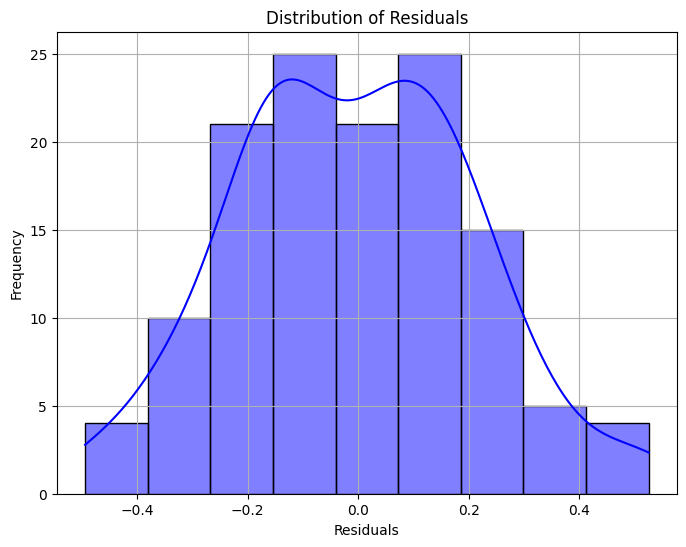

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor.fit(X_train, y_train)
y_pred = gb_regressor.predict(X_test)
add_to_metrics(y_test,y_pred,"GB")
visualize_results(y_test,y_pred)

In [29]:
y_pred2 = gb_regressor.predict(X_test2)
y_pred2

array([0.45037744])

# ***Extreme Gradient Boosting***

Mean Absolute Error (MAE): 0.1752078075867174
Mean Squared Error (MSE): 0.049761288783877304
Root Mean Squared Error (RMSE): 0.2230723846285714
R-squared (R²) Score: 0.42563798236702655


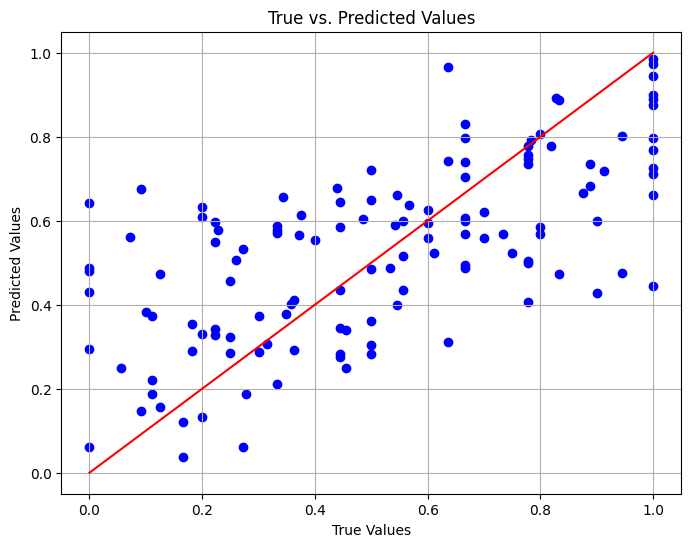

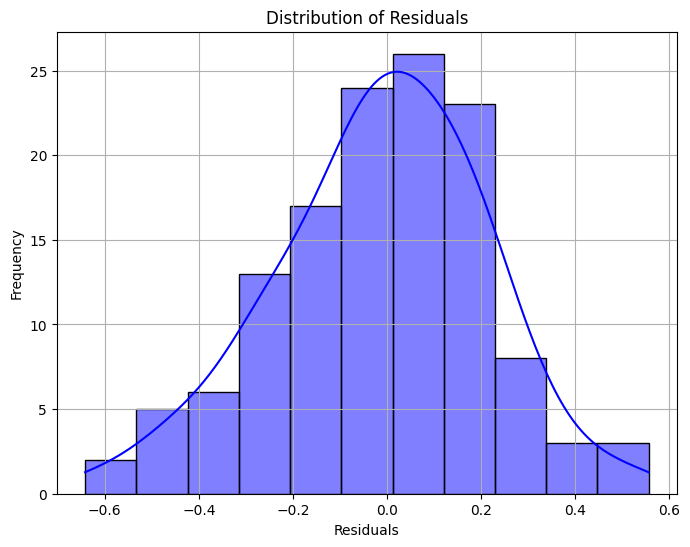

In [30]:
import xgboost as xgb

xgb_regressor = xgb.XGBRegressor(random_state=42)
xgb_regressor.fit(X_train, y_train)
y_pred = xgb_regressor.predict(X_test)
add_to_metrics(y_test,y_pred,"XGB")
visualize_results(y_test,y_pred)

In [31]:
y_pred2 = xgb_regressor.predict(X_test2)
y_pred2

array([0.5049839], dtype=float32)

# ***LightGBM***

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1595
[LightGBM] [Info] Number of data points in the train set: 388, number of used features: 39
[LightGBM] [Info] Start training from score 0.507963
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

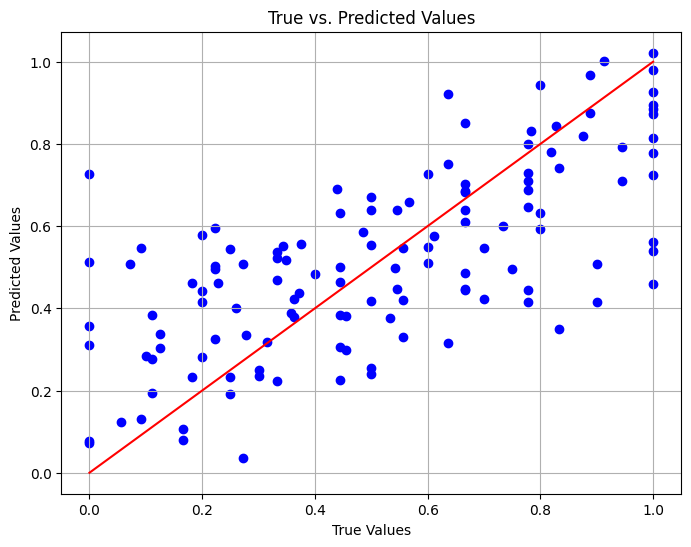

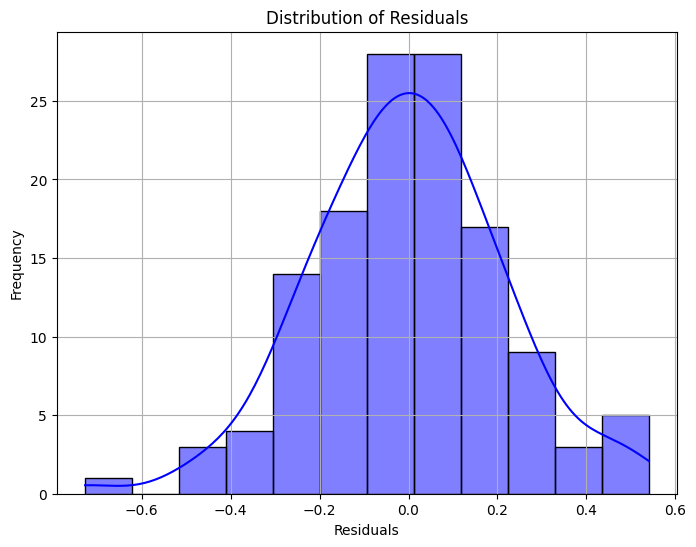

In [47]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
params = {'objective': 'regression', 'random_state': 42, 'learning_rate': 0.1, 'num_iterations': 1000}
lgb_regressor = lgb.train(params, train_data)
y_pred = lgb_regressor.predict(X_test)
add_to_metrics(y_test,y_pred,"LGB")
visualize_results(y_test,y_pred)

In [ ]:
y_pred2 = lgb_regressor.predict(X_test2)
y_pred2

array([0.44541787])

# ***SVR RBF Kernel***

Mean Absolute Error (MAE): 0.17160680504510004
Mean Squared Error (MSE): 0.04365273377493929
Root Mean Squared Error (RMSE): 0.20893236650873243
R-squared (R²) Score: 0.4961450384642635


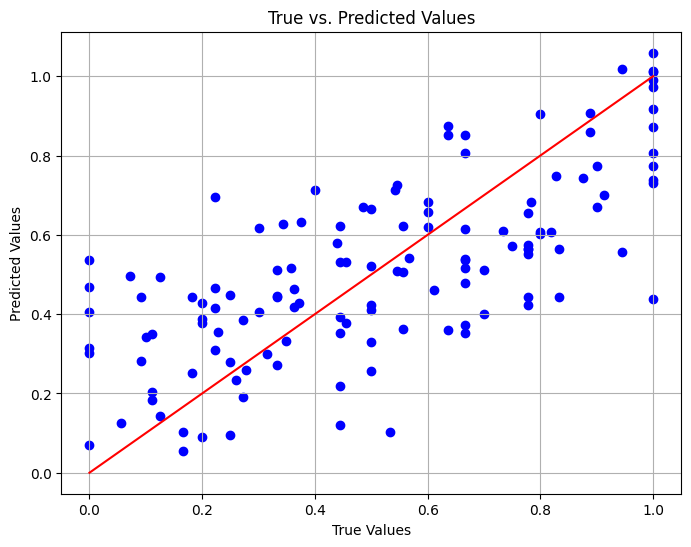

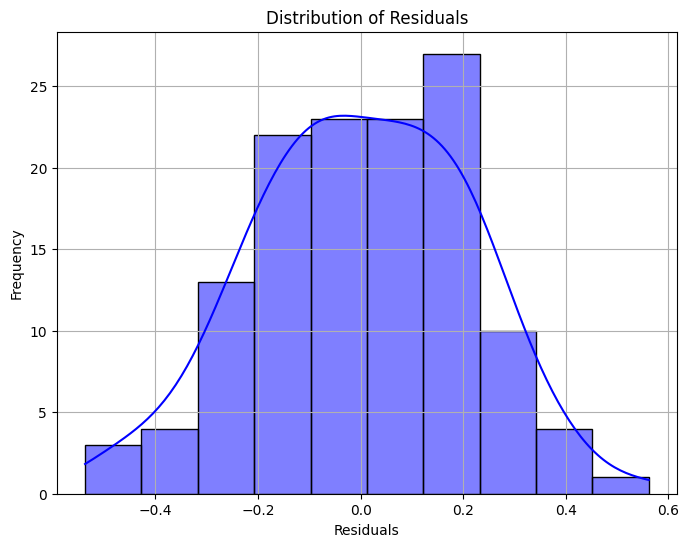

In [33]:
from sklearn.svm import SVR

rbf_svr = SVR(kernel='rbf')
rbf_svr.fit(X_train, y_train)
y_pred = rbf_svr.predict(X_test)
add_to_metrics(y_test,y_pred,"SVM")
visualize_results(y_test,y_pred)

In [34]:
y_pred2 = rbf_svr.predict(X_test2)
y_pred2

array([0.56361394])

# ***Ridge Regression***

Mean Absolute Error (MAE): 0.18774295298924
Mean Squared Error (MSE): 0.0543085068389331
Root Mean Squared Error (RMSE): 0.2330418564098156
R-squared (R²) Score: 0.3731524177735881


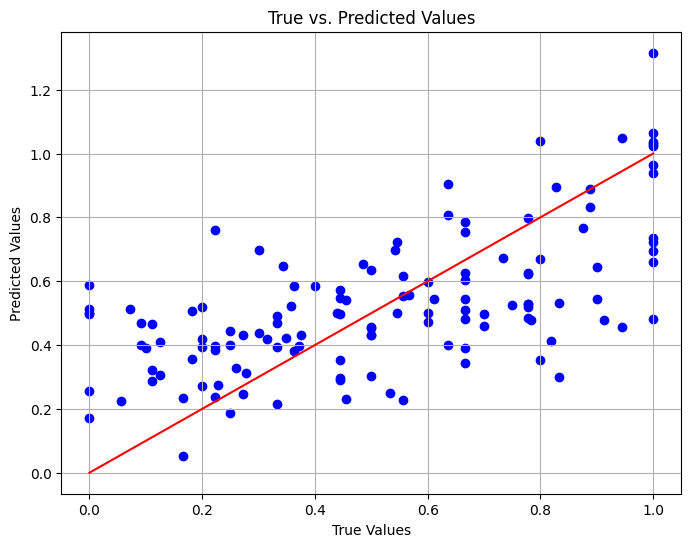

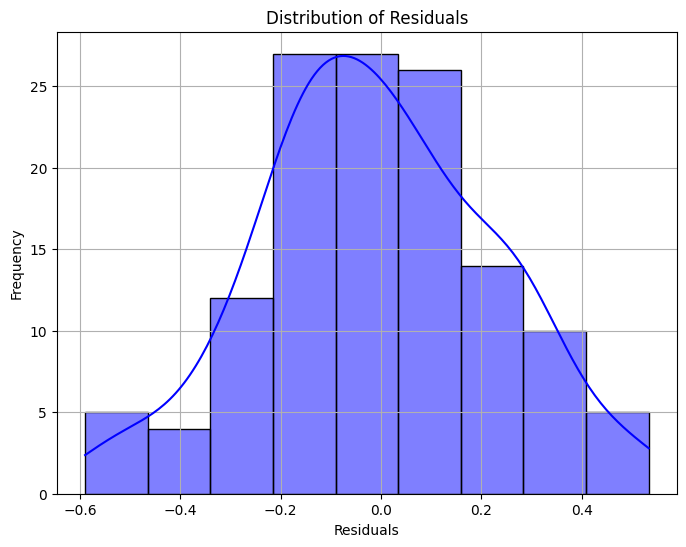

In [35]:
from sklearn.linear_model import Ridge

alpha = 1.0
ridge_reg = Ridge(alpha=alpha)
ridge_reg.fit(X_train, y_train)
y_pred = ridge_reg.predict(X_test)
add_to_metrics(y_test,y_pred,"Ridge")
visualize_results(y_test,y_pred)

In [36]:
y_pred2 = ridge_reg.predict(X_test2)
y_pred2

array([0.62333205])

# ***Lasso Regression***

Mean Absolute Error (MAE): 0.25169012903526583
Mean Squared Error (MSE): 0.08668283078321998
Root Mean Squared Error (RMSE): 0.2944194809845639
R-squared (R²) Score: -0.0005232340147705017


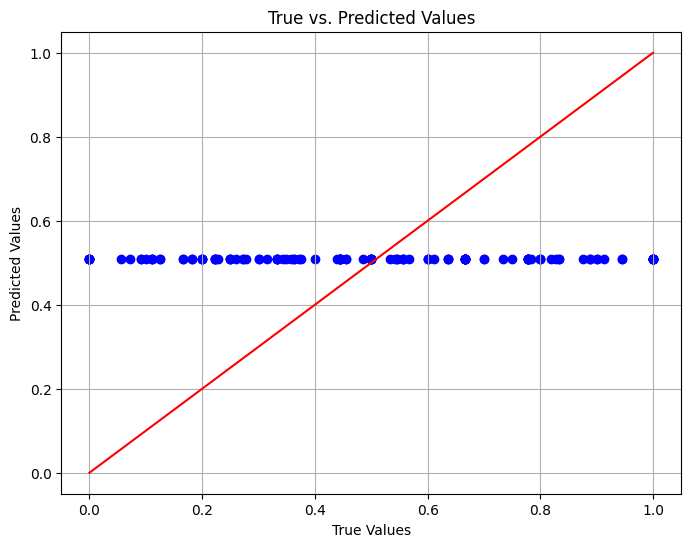

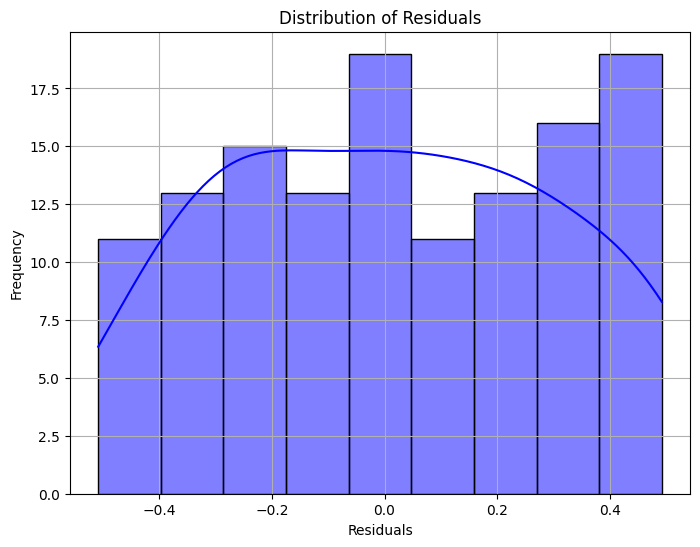

In [37]:
from sklearn.linear_model import Lasso

alpha = 0.1
lasso_reg = Lasso(alpha=alpha)
lasso_reg.fit(X_train_orig, y_train_orig)
y_pred = lasso_reg.predict(X_test_orig)
add_to_metrics(y_test_orig,y_pred,"Lasso")
visualize_results(y_test_orig,y_pred)

In [38]:
y_pred2 = lasso_reg.predict(X_test2_orig)
y_pred2

array([0.50796279])

In [39]:
# import numpy as np
# from sklearn.linear_model import Lasso

# # Create a Lasso model
# model = Lasso()

# # Fit the model
# model.fit(X_train_orig, y_train_orig)

# # Access coefficients
# coefficients = model.coef_

# # Print features and their coefficients
# print("Features:", features_orig)
# print("Coefficients:", coefficients)

# # Identify features with zero coefficients (selected features)
# selected_features = np.where(coefficients == 0)[0]

# # Print selected features
# print("Selected features:", [features_orig[i] for i in selected_features])

# # Analyze non-zero coefficients for relative importance
# non_zero_features = np.where(coefficients != 0)[0]
# importance = np.abs(coefficients[non_zero_features])

# # Print features and their relative importance
# print("Feature importance (example):")
# for i, feature in enumerate(non_zero_features):
#     print(f"{features_orig[i]}: {importance[i]}")


# ***ANN***

In [40]:
# import tensorflow as tf
# from tensorflow import keras

# model = keras.Sequential([
#   keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#   keras.layers.Dense(64, activation='relu'),
#   keras.layers.Dense(1)
# ])
# model.compile(loss='mse', optimizer='adam')
# model.fit(X_train, y_train, epochs=10, batch_size=32)
# y_pred = model.predict(X_test)
# y_pred = np.squeeze(y_pred)
# add_to_metrics(y_test,y_pred,"ANN")
# visualize_results(y_test,y_pred)

In [41]:
# y_pred2 = model.predict(X_test2)
# y_pred2 = np.squeeze(y_pred2)
# y_pred2

# ***Comparing model performances***

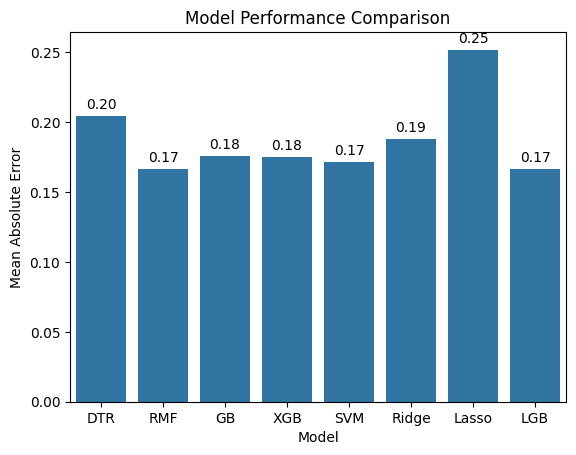

In [48]:
axis = sns.barplot(x = 'Name', y = 'mae', data = pd.DataFrame({'Name': names, 'mae': mae}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='Mean Absolute Error')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

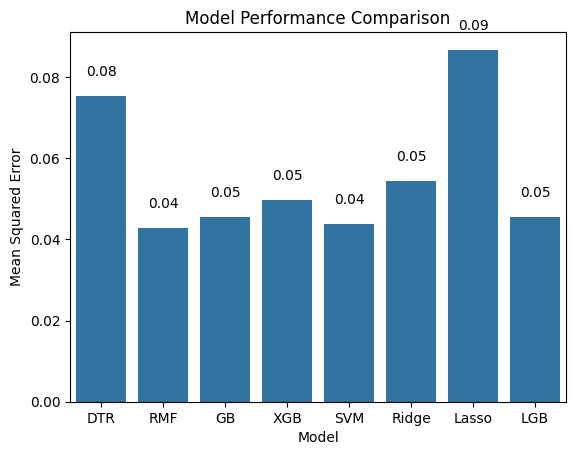

In [49]:
axis = sns.barplot(x = 'Name', y = 'mse', data = pd.DataFrame({'Name': names, 'mse': mse}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='Mean Squared Error')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

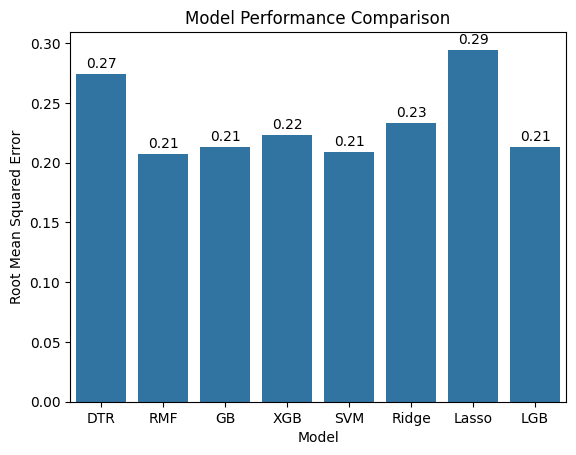

In [50]:
axis = sns.barplot(x = 'Name', y = 'rmse', data = pd.DataFrame({'Name': names, 'rmse': rmse}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='Root Mean Squared Error')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

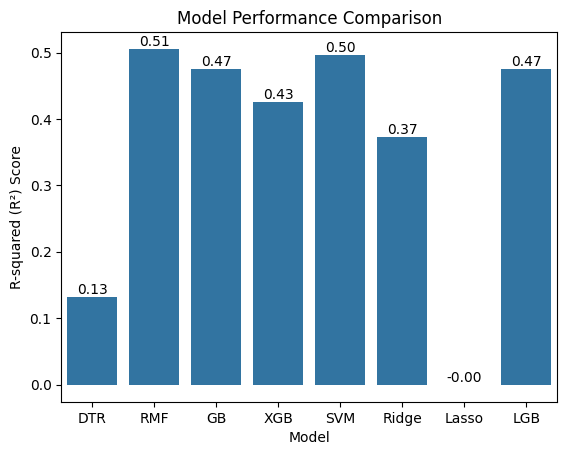

In [51]:
axis = sns.barplot(x = 'Name', y = 'r2', data = pd.DataFrame({'Name': names, 'r2': r2}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='R-squared (R²) Score')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

In [52]:
print(mae)
print(mse)
print(rmse)
print(r2)

[0.20444041385345735, 0.16651062116627335, 0.1758328611577662, 0.1752078075867174, 0.17160680504510004, 0.18774295298924, 0.25169012903526583, 0.1664450129502629]
[0.07524812599474064, 0.042845669091130446, 0.045499146510074466, 0.049761288783877304, 0.04365273377493929, 0.0543085068389331, 0.08668283078321998, 0.04551661826952752]
[0.2743139187039926, 0.20699195417003638, 0.21330528945639032, 0.2230723846285714, 0.20893236650873243, 0.2330418564098156, 0.2944194809845639, 0.21334624034542424]
[0.13146008622986793, 0.5054604583716144, 0.4748331036279001, 0.42563798236702655, 0.4961450384642635, 0.3731524177735881, -0.0005232340147705017, 0.47463143853327916]


# ***Hyper Tuning Ridge & Lasso***

In [53]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import Ridge, Lasso
# from sklearn.model_selection import RandomizedSearchCV

# # Define parameter distributions for randomized search
# param_dist = {
#     "alpha": np.logspace(-3, 2, 50)  # Explore lambda values from 0.001 to 100 on a log scale
# }

# # Define randomized search objects
# ridge_search = RandomizedSearchCV(Ridge(), param_dist, n_iter=100, cv=3)  # 100 random trials, 5-fold CV
# lasso_search = RandomizedSearchCV(Lasso(), param_dist, n_iter=100, cv=3)  # Same settings

# # Perform randomized search for Ridge and Lasso
# ridge_search.fit(X_train, y_train)
# lasso_search.fit(X_train_orig, y_train_orig)

# # Best models for Ridge and Lasso
# best_ridge = ridge_search.best_estimator_
# best_lasso = lasso_search.best_estimator_

# # Best parameters for Ridge and Lasso
# best_lambda_ridge = ridge_search.best_params_["alpha"]
# best_lambda_lasso = lasso_search.best_params_["alpha"]

# # Function to get coefficients for different lambda values
# def get_coef_path(model, lambda_range):
#     coef_path = []
#     for lambd in lambda_range:
#         model.set_params(alpha=lambd)
#         model.fit(X_train, y_train)
#         coef_path.append(model.coef_)
#     return np.array(coef_path)

# # Get regularization paths for Ridge and Lasso
# ridge_coef_path = get_coef_path(Ridge(), lambda_range=np.logspace(-3, 2, 50))
# lasso_coef_path = get_coef_path(Lasso(), lambda_range=np.logspace(-3, 2, 50))

# # Plot the regularization paths
# plt.figure(figsize=(20, 6))
#  # Assuming the original feature names

# # Handle potential index out-of-bounds issue
# max_features = min(len(ridge_coef_path[0]), len(lasso_coef_path[0]), len(features_orig))
# features_to_plot = features_orig[:max_features]  # Truncate features if necessary

# for i, feature in enumerate(features_to_plot):
#     plt.plot(np.logspace(-3, 2, 50), ridge_coef_path[:, i], label=f"Ridge - {feature}")
#     plt.plot(np.logspace(-3, 2, 50), lasso_coef_path[:, i], label=f"Lasso - {feature}")

# plt.xlabel("Lambda (alpha)")
# plt.ylabel("Coefficient value")
# plt.title("Regularization Path for Ridge and Lasso")
# plt.legend()
# plt.semilogx()  # Use semilogx for better visualization on a log scale
# plt.grid(True)
# plt.show()

# # Print best lambda values
# print(f"Best lambda for Ridge: {best_lambda_ridge}")
# print(f"Best lambda for Lasso: {best_lambda_lasso}")

# # Use the best model for prediction
# print("Best Ridge Model Prediction:")
# y_pred = best_ridge.predict(X_test)
# add_to_metrics(y_test,y_pred,"HRidge")
# visualize_results(y_test,y_pred)

# print("Best Lasso Model Prediction:")
# y_pred = best_lasso.predict(X_test_orig)
# add_to_metrics(y_test_orig,y_pred,"HLasso")
# visualize_results(y_test_orig,y_pred)

In [54]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import RandomizedSearchCV

# # Define parameter distributions for randomized search
# param_dist = {
#     "alpha": np.logspace(-3, 2, 50)  # Explore lambda values from 0.001 to 100 on a log scale
# }

# # Define randomized search objects
# ridge_search = RandomizedSearchCV(Ridge(), param_dist, n_iter=100, cv=3)

# # Perform randomized search for Ridge
# ridge_search.fit(X_train, y_train)

# # Best models for Ridge
# best_ridge = ridge_search.best_estimator_

# # Best parameters for Ridge
# best_lambda_ridge = ridge_search.best_params_["alpha"]

# # Function to get coefficients for different lambda values
# def get_coef_path(model, lambda_range):
#     coef_path = []
#     for lambd in lambda_range:
#         model.set_params(alpha=lambd)
#         model.fit(X_train, y_train)
#         coef_path.append(model.coef_)
#     return np.array(coef_path)

# # Get regularization paths for Ridge
# ridge_coef_path = get_coef_path(Ridge(), lambda_range=np.logspace(-3, 2, 50))

# # Plot the regularization paths
# plt.figure(figsize=(20, 6))
#  # Assuming the original feature names

# # Handle potential index out-of-bounds issue
# max_features = min(len(ridge_coef_path[0]), len(features_orig))
# features_to_plot = features_orig[:max_features]  # Truncate features if necessary

# for i, feature in enumerate(features_to_plot):
#     plt.plot(np.logspace(-3, 2, 50), ridge_coef_path[:, i], label=f"Ridge - {feature}")

# plt.xlabel("Lambda (alpha)")
# plt.ylabel("Coefficient value")
# plt.title("Regularization Path for Ridge")
# plt.legend()
# plt.semilogx()  # Use semilogx for better visualization on a log scale
# plt.grid(True)
# plt.show()

# # Print best lambda values
# print(f"Best lambda for Ridge: {best_lambda_ridge}")

# # Use the best model for prediction
# print("Best Ridge Model Prediction:")
# y_pred = best_ridge.predict(X_test)
# add_to_metrics(y_test,y_pred,"HRidge")
# visualize_results(y_test,y_pred)

In [55]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import Lasso
# from sklearn.model_selection import RandomizedSearchCV

# # Define parameter distributions for randomized search
# param_dist = {
#     "alpha": np.logspace(-5, -1, 50)  # Explore lambda values from 0.001 to 100 on a log scale
# }

# # Define randomized search objects
# lasso_search = RandomizedSearchCV(Lasso(), param_dist, n_iter=100, cv=3)

# # Perform randomized search for Lasso
# lasso_search.fit(X_train_orig, y_train_orig)

# # Best models for Lasso
# best_lasso = lasso_search.best_estimator_

# # Best parameters for Lasso
# best_lambda_lasso = lasso_search.best_params_["alpha"]

# # Function to get coefficients for different lambda values
# def get_coef_path(model, lambda_range):
#     coef_path = []
#     for lambd in lambda_range:
#         model.set_params(alpha=lambd)
#         model.fit(X_train, y_train)
#         coef_path.append(model.coef_)
#     return np.array(coef_path)

# # Get regularization paths for Lasso
# lasso_coef_path = get_coef_path(Lasso(), lambda_range=np.logspace(-5, -1, 50))

# # Plot the regularization paths
# plt.figure(figsize=(20, 6))
#  # Assuming the original feature names

# # Handle potential index out-of-bounds issue
# max_features = min(len(lasso_coef_path[0]), len(features_orig))
# features_to_plot = features_orig[:max_features]  # Truncate features if necessary

# for i, feature in enumerate(features_to_plot):
#     plt.plot(np.logspace(-5, -1, 50), lasso_coef_path[:, i], label=f"Lasso - {feature}")

# plt.xlabel("Lambda (alpha)")
# plt.ylabel("Coefficient value")
# plt.title("Regularization Path for Lasso")
# plt.legend()
# plt.semilogx()  # Use semilogx for better visualization on a log scale
# plt.grid(True)
# plt.show()

# # Print best lambda values
# print(f"Best lambda for Lasso: {best_lambda_lasso}")

# print("Best Lasso Model Prediction:")
# y_pred = best_lasso.predict(X_test_orig)
# add_to_metrics(y_test_orig,y_pred,"HLasso")
# visualize_results(y_test_orig,y_pred)

# ***Downloading PKL Files***

In [56]:
with open('features.txt', 'w') as file:
    for feature in features:
        file.write(feature + '\n')

In [57]:
with open('normalize_these.txt', 'w') as file:
    for feature in normalize_these:
        file.write(feature + '\n')

In [58]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [59]:
with open('order_model.pkl', 'wb') as file:
    pickle.dump(rbf_svr, file)

In [60]:
# If ANN is chosen
# with open('le1.pkl', 'wb') as file:
#     pickle.dump(le1, file)
# files.download("le1.pkl")

# ***PLAY SOUND ONCE ALL THE CODES ARE EXECUTED***

In [176]:
from IPython.display import HTML
# Display the HTML element
display(HTML(f"""<audio controls autoplay loop><source src='http://codeskulptor-demos.commondatastorage.googleapis.com/descent/gotitem.mp3' type="audio/mpeg"></audio>"""))